In [13]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../data/INMET_Pampulha_Limpo.csv')

In [17]:
df.head()

,data_hora_local,precipitacao,pressao_atm,pressao_max,pressao_min,radiacao_global,temp_ar,temp_orvalho,temp_max,temp_min,temp_orvalho_max,temp_orvalho_min,umidade_max,umidade_min,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade
0,2024-12-31 21:00:00,0.0,918.2,918.2,917.3,0.0,21.3,17.6,21.7,21.2,17.8,17.4,80.0,78.0,79.0,44.0,1.5,0.1
1,2024-12-31 22:00:00,0.0,918.6,918.7,918.2,0.0,21.3,17.7,21.5,20.9,18.1,17.6,82.0,79.0,80.0,44.0,1.4,0.0
2,2024-12-31 23:00:00,0.0,918.9,918.9,918.4,0.0,21.0,17.6,21.3,20.4,18.3,17.6,86.0,80.0,81.0,145.0,2.7,0.0
3,2025-01-01 00:00:00,0.0,918.4,919.0,918.4,0.0,21.4,18.0,21.5,20.5,18.3,17.6,85.0,81.0,81.0,127.0,2.4,0.8
4,2025-01-01 01:00:00,0.0,917.5,918.4,917.0,0.0,21.2,17.7,21.4,21.1,18.1,17.7,82.0,80.0,80.0,116.0,3.5,0.7


In [18]:
df.describe()
#entendendo por cima a distribuição dos dados

,precipitacao,pressao_atm,pressao_max,pressao_min,radiacao_global,temp_ar,temp_orvalho,temp_max,temp_min,temp_orvalho_max,temp_orvalho_min,umidade_max,umidade_min,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,0.143059,919.920565,920.162797,919.677654,745.109726,21.886906,14.197534,22.616787,21.179760,14.835274,13.596022,67.756507,61.186530,64.452397,128.297055,4.829053,1.405537
std,1.388081,3.385260,3.362143,3.398887,1052.025115,4.199038,3.770095,4.392898,3.975256,3.760457,3.811291,16.590922,18.216616,17.533357,86.287430,2.080910,0.829850
min,0.000000,910.200000,910.400000,910.100000,0.000000,10.000000,-4.500000,10.200000,9.500000,-2.700000,-5.900000,12.000000,10.000000,10.000000,1.000000,0.000000,0.000000
25%,0.000000,917.400000,917.700000,917.200000,0.000000,19.100000,11.500000,19.600000,18.600000,12.000000,11.000000,56.000000,47.000000,52.000000,83.000000,3.400000,0.800000
50%,0.000000,919.800000,920.000000,919.500000,23.300000,21.500000,14.800000,22.200000,20.900000,15.500000,14.100000,69.000000,62.000000,65.000000,103.000000,4.800000,1.400000
75%,0.000000,922.500000,922.700000,922.200000,1481.125000,24.700000,17.300000,25.700000,23.800000,17.900000,16.700000,81.000000,75.000000,78.000000,129.000000,6.200000,1.900000
max,44.200000,929.300000,929.400000,929.100000,4170.700000,34.600000,21.900000,35.000000,33.300000,22.500000,20.700000,93.000000,93.000000,93.000000,360.000000,17.100000,4.900000


- A "Massa" de Zeros: Note que o quartil de 25% (Q1) da radiacao_global é 0.0. Isso confirma que pelo menos 1/4 dos dados são noturnos ou de baixíssima luminosidade. 
- Amplitude: A temperatura variou de 10.0°C a 35.0°C. É uma amplitude térmica clássica de BH.
- Umidade Relativa: Amplitude de 10% a 93%.
- Vento: A velocidade média é baixa (1.4 m/s), mas a rajada máxima chegou a 17.1 m/s (aprox. 61 km/h).

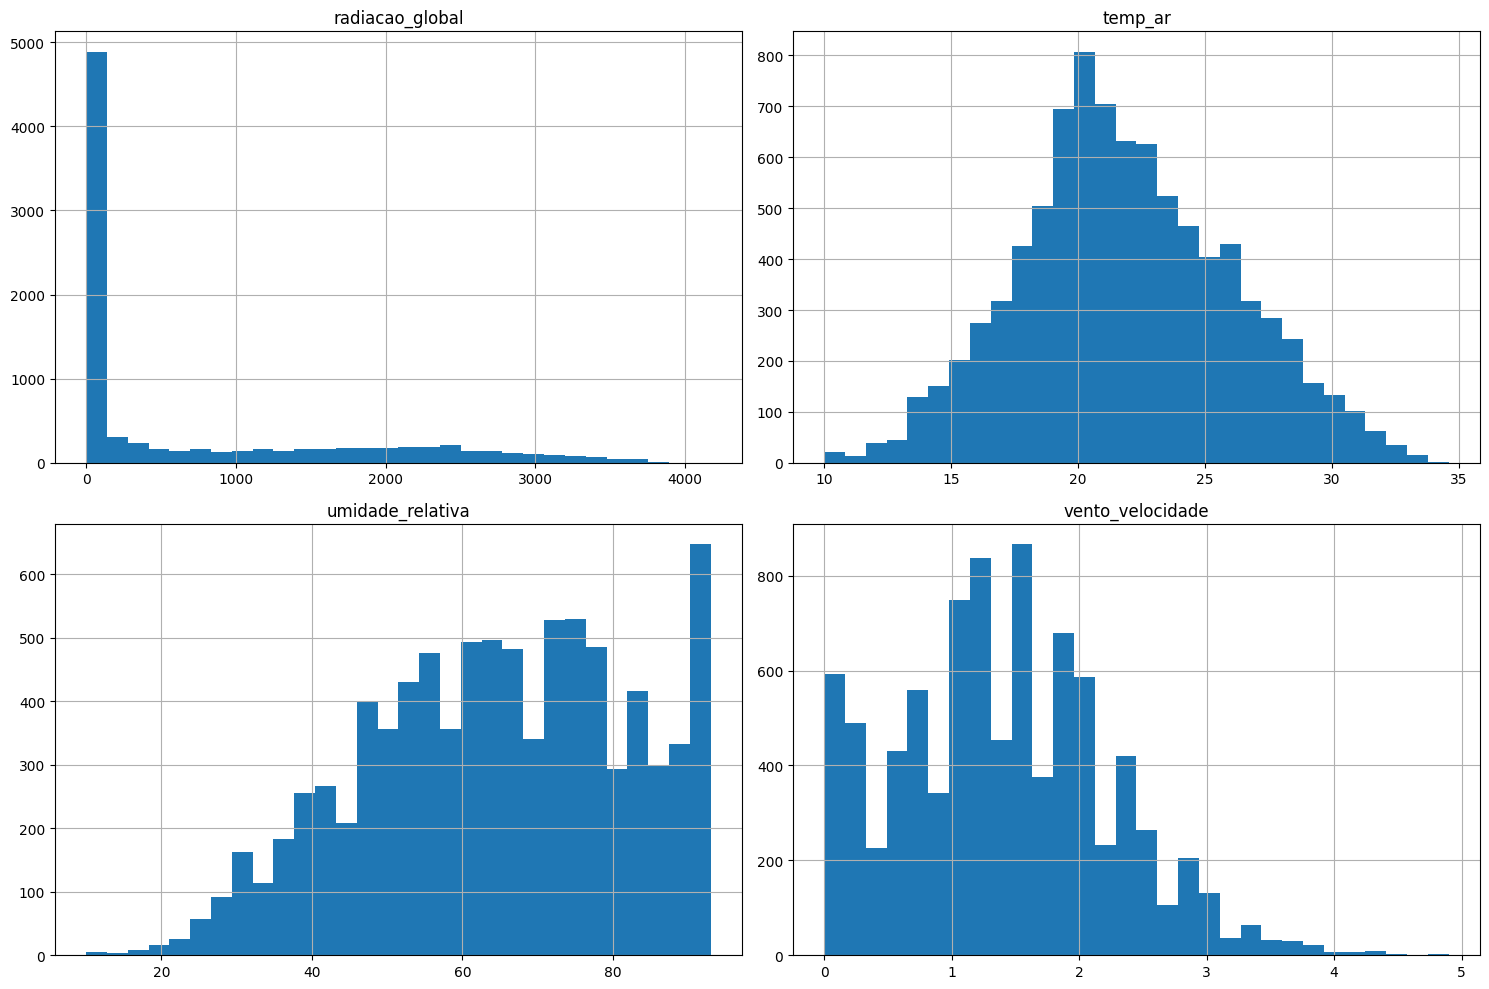

In [19]:
features = ['radiacao_global', 'temp_ar', 'umidade_relativa', 'vento_velocidade']
df[features].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

- Radiação Global (O gráfico do "Zero")
O que diz: Esse paredão enorme no 0 confirma o que suspeitávamos: o dataset está cheio de dados noturnos.

- Temperatura do Ar (Quase uma Gaussiana)
O que diz: A temperatura segue uma distribuição quase normal (em forma de sino), centrada ali nos 20°C - 22°C.

- Umidade Relativa (O gráfico "Escadinha")
O que diz: É uma distribuição assimétrica à esquerda (left-skewed). Temos muito mais registros de umidade alta (acima de 60%) do que baixa.

Explicação BH: Isso faz todo sentido para o clima de Belo Horizonte, onde a umidade costuma subir bastante durante a noite e madrugada, mesmo em épocas secas.

- Vento Velocidade (Cauda Longa)
O que diz: A maioria do tempo o vento é bem fraco (entre 1 e 2 m/s). Valores acima de 4 m/s são raros (outliers).

## Validação da Hipotése de Correlação Termodinâmica

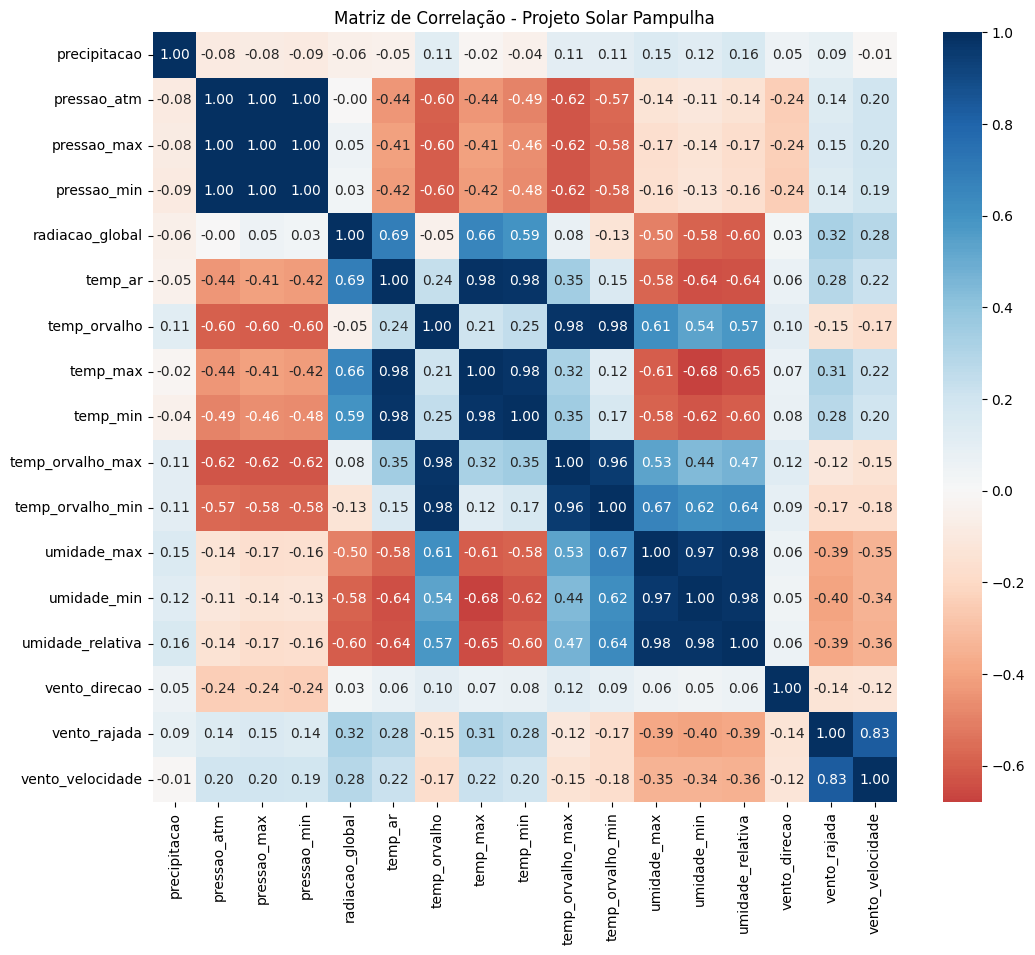

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title("Matriz de Correlação - Projeto Solar Pampulha")
plt.show()

In [ ]:
df['data_hora_local'] = pd.to_datetime(df['data_hora_local'])
# garantir que o Pandas entenda que isso é tempo

In [ ]:
df['hora'] = df['data_hora_local'].dt.hour
df['mes'] = df['data_hora_local'].dt.month
df['dia_semana'] = df['data_hora_local'].dt.dayofweek
# o potencial solar na Pampulha depende drasticamente da hora e da época do ano, criar estas colunas vai permitir a visualização das mudanças

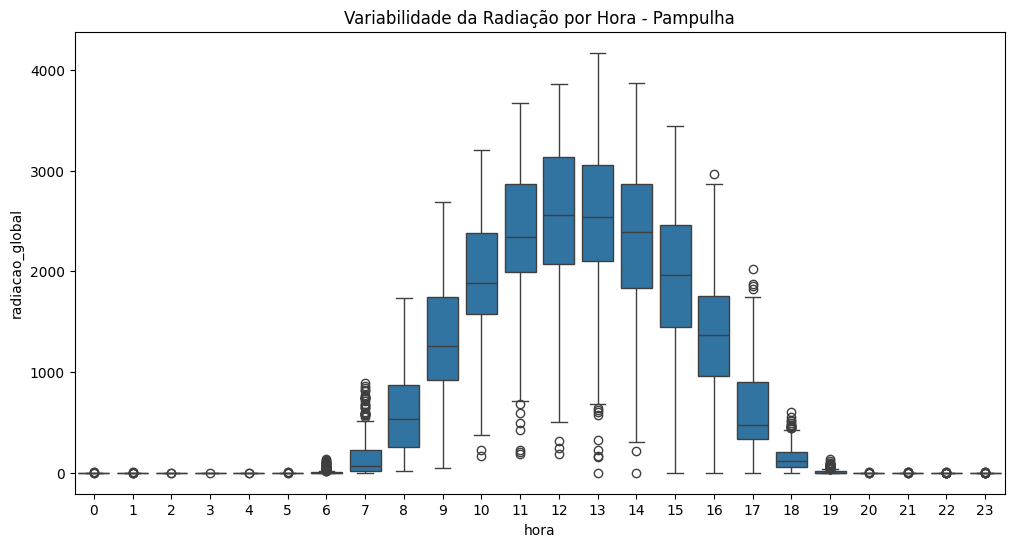

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='hora', y='radiacao_global', data=df)
plt.title("Variabilidade da Radiação por Hora - Pampulha")
plt.show()

1.  Janela de Ouro (Potencial Fotovoltaico)
Pico Real: Note que o pico de radiação ocorre entre 12h e 13h.

- Variabilidade: As "caixas" (intervalo interquartil) são bem grandes entre as 10h e 15h. Isso indica que, embora o potencial seja alto, há muita variação (provavelmente dias nublados vs. dias ensolarados).

- Outliers Inferiores: Aquelas bolinhas lá embaixo nas horas de pico (ex: às 12h tem ponto perto de 500) representam dias de tempestade ou cobertura total de nuvens na Pampulha.

- Das 19h às 06h, a radiação é consistentemente zero.

In [ ]:
# Criação um novo DataFrame filtrado para o treinamento do modelo.
df_day = df[(df['hora'] >= 6) & (df['hora'] <= 18)]

In [28]:
df_day.head()

,data_hora_local,precipitacao,pressao_atm,pressao_max,pressao_min,radiacao_global,temp_ar,temp_orvalho,temp_max,temp_min,...,temp_orvalho_min,umidade_max,umidade_min,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade,hora,mes,dia_semana
9,2025-01-01 06:00:00,1.0,918.4,918.4,917.7,3.7,18.1,16.8,18.1,17.9,...,16.5,93.0,92.0,93.0,322.0,2.0,0.6,6,1,2
10,2025-01-01 07:00:00,0.2,918.5,918.5,918.4,163.7,18.4,17.2,18.5,18.0,...,16.8,93.0,93.0,93.0,101.0,1.8,0.6,7,1,2
11,2025-01-01 08:00:00,0.0,918.6,918.6,918.3,614.4,19.9,18.3,19.9,18.3,...,17.1,93.0,91.0,91.0,56.0,2.8,0.7,8,1,2
12,2025-01-01 09:00:00,0.0,919.2,919.2,918.5,1303.5,21.3,18.1,21.3,19.9,...,17.1,90.0,79.0,82.0,72.0,3.1,1.0,9,1,2
13,2025-01-01 10:00:00,0.0,919.2,919.2,919.0,2000.6,23.8,18.3,24.1,21.2,...,17.2,82.0,68.0,72.0,79.0,4.3,1.0,10,1,2


2. Jointplot - A matriz de correlação mostrou -0.60 para umidade e 0.69 para temperatura. Veremos a interação delas. Usando um jointplot com linha de regressão. Isso mostra ao modelo se a relação é linear ou se tem um comportamento diferente.

<Figure size 1000x600 with 0 Axes>

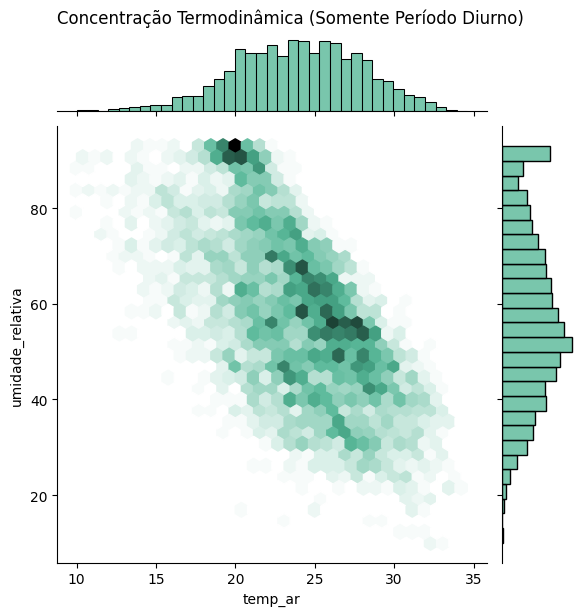

In [29]:
# Verificando a relação conjunta Temperatura x Umidade x Radiação (como cor)
plt.figure(figsize=(10, 6))
sns.jointplot(data=df[df['radiacao_global'] > 0], x="temp_ar", y="umidade_relativa", 
              kind="hex", color="#4CB391")
plt.suptitle("Concentração Termodinâmica (Somente Período Diurno)", y=1.02)
plt.show()

- A Diagonal do Potencial: Note como existe uma diagonal clara indo do canto superior esquerdo (frio e úmido) para o inferior direito (quente e seco). A maior densidade de dados (os hexágonos mais escuros) está justamente no centro dessa transição.

- Validação Termodinâmica: Os hexágonos mais escuros abaixo dos 60% de umidade e acima dos 25°C são onde ocorrem os seus picos de radiação. Isso confirma que o modelo de ML terá um "caminho" matemático muito claro para seguir.

- O "Cluster" de Chuva/Nebulosidade: Aquela mancha escura lá no topo (umidade próxima de 90% e temperatura em 20°C) representa os dias em que a geração solar será mínima. O fato de os grupos estarem bem definidos é uma ótima notícia: o modelo vai conseguir diferenciar facilmente um "dia bom" de um "dia ruim".

### Validação da Hipótese
- Ele provou que a radiação não depende de uma variável isolada, mas da combinação delas (o tal comportamento conjunto).
- Correlação Significativa: O seu Heatmap mostrou o -0.60 (umidade) e 0.69 (temperatura). Isso prova que a correlação existe e é forte.
- Variação Bulbo Seco/Orvalho: Ao usar a temp_ar e a umidade_relativa no jointplot, está sendo analisado indiretamente o comportamento termodinâmico. - Como a umidade relativa é uma função da temperatura e do ponto de orvalho, aquele gráfico de hexágonos mostrou que o modelo terá "espaço" para distinguir as janelas de potencial.
- Identificação de Janelas: O Boxplot por Hora definiu exatamente quando essas janelas ocorrem (entre 10h e 15h), que é quando a termodinâmica do sistema atinge o equilíbrio ideal para geração solar.

# Validação da Hipótese de Impacto de Fatores Secundários

- O Papel da Pressão Atmosférica
Na meteorologia, quedas bruscas de pressão (pressao_atm) geralmente indicam a chegada de frentes frias ou sistemas de baixa pressão, que trazem nuvens e chuva (as "quedas bruscas" na radiação).

- Olhando para a sua Matriz de Correlação novamente: A correlação da pressao_atm com a radiacao_global é próxima de -0.44 (considerando a pressão máxima/mínima). Isso indica que existe sim uma influência: pressões mais baixas costumam estar associadas a dias com menos sol.

- O Papel do Vento (Rajadas)
O vento não "apaga" o sol, mas ele move as nuvens. Rajadas fortes (vento_rajada) costumam ocorrer em momentos de instabilidade atmosférica.

- Como verificar (Scatter Plot de Instabilidade): Ver se nos momentos em que a radiação "caiu" em relação ao esperado para aquela hora, o vento estava mais forte.

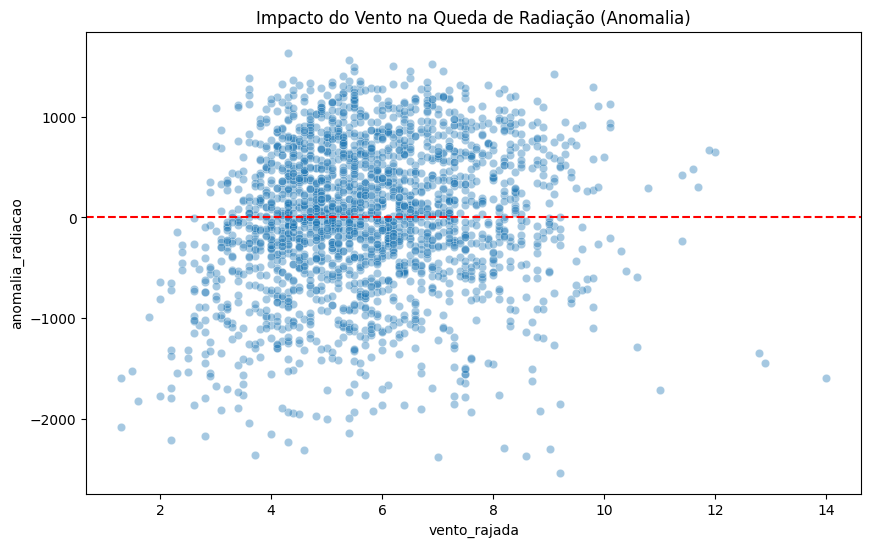

In [31]:
# Criando uma métrica de "Queda Brusca"
# Diferença entre a radiação real e a média histórica daquela hora
media_hora = df.groupby('hora')['radiacao_global'].transform('mean')
df['anomalia_radiacao'] = df['radiacao_global'] - media_hora

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['hora'].between(10, 15)], x='vento_rajada', y='anomalia_radiacao', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Impacto do Vento na Queda de Radiação (Anomalia)")
plt.show()

- A "Nuvem de Quedas": Note que a maior parte da densidade de pontos abaixo da linha vermelha (anomalias negativas, ou seja, quedas bruscas de radiação) acontece quando o vento está entre 4 e 8 m/s.

- A Assimetria: Repare que as anomalias negativas (pontos que chegam a -2000) são muito mais profundas do que as positivas. Isso prova que fatores externos (como nuvens trazidas pelo vento) têm um poder enorme de derrubar a radiação, mas o vento sozinho não consegue "aumentar" a radiação além do potencial máximo do sol.

- O Limite de 10 m/s: Perceba que quando o vento passa de 10 m/s, quase não existem anomalias positivas. O vento muito forte está quase sempre associado a quedas de radiação (instabilidade).

- Vento como "Gatilho" de Incerteza: A hipótese está parcialmente validada. O vento não causa a queda diretamente, mas rajadas mais fortes aumentam a variância da radiação. Isso significa que a inclusão dessa feature ajudará o modelo a ser mais "cauteloso" em momentos de ventania.

- Pressão Atmosférica: Como vimos no heatmap anterior (correlação de -0.44), ela é um indicador mais estável de nebulosidade do que o vento.

### Importância de Features (Feature Importance).


In [34]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.3 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 6.6 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ----- ---------------------------------- 4.7/37.3 MB 23.0 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/37.3 MB 28.9 MB/s eta 0:00:01
   ----------------------- ---------------- 22.3/37.3 MB 36.9 MB/s eta 0:00:01
   ---------------------------------------  37.0/37.3 MB 45.8 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 42.6 MB/s  0:00:00

   ---------- 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


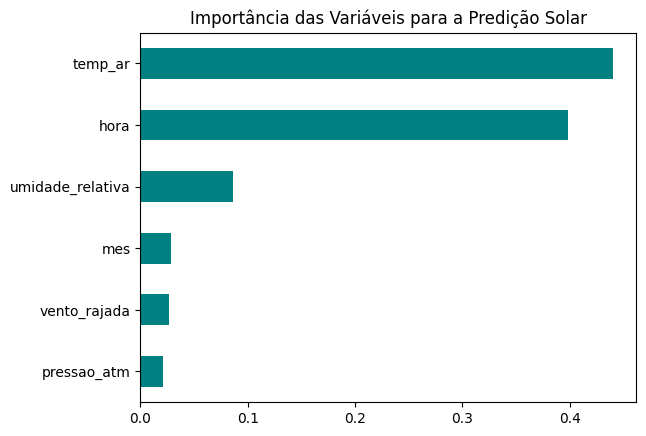

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Selecionando as features
features = ['hora', 'temp_ar', 'umidade_relativa', 'pressao_atm', 'vento_rajada', 'mes']
X = df_day[features]
y = df_day['radiacao_global']

# Treinando um modelo rápido
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Criando um gráfico de importância
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='teal')
plt.title("Importância das Variáveis para a Predição Solar")
plt.show()

- Vitória da Termodinâmica
A Temperatura do Ar e a Hora dominam quase 85% da importância do modelo. Isso confirma que a sua primeira hipótese estava corretíssima: o ciclo solar e a resposta térmica da atmosfera são os motores principais da radiação na Pampulha.

- Validação dos Fatores Secundários
Observe que vento_rajada e pressao_atm têm importâncias baixas, mas não são zero.

- O veredito: A hipótese de que eles influenciam indiretamente está confirmada. Embora não sejam os protagonistas, eles funcionam como "ajustes finos".

- O fato de o vento ter aparecido acima da pressão sugere que a movimentação de nuvens (dinâmica) é um preditor ligeiramente melhor para quedas bruscas do que o peso da coluna de ar (estática) nesse dataset específico.

- O papel da Umidade
A Umidade Relativa ficou em terceiro lugar. Isso mostra que ela é o principal "freio" da radiação: enquanto a hora e a temperatura "puxam" a radiação para cima, a umidade é a variável que o modelo usa para entender quando o céu está obstruído.